<a href="https://colab.research.google.com/github/amitgupta226571/DEEP-LEARNING-/blob/main/Experiment_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Set path for Experiment 9
import os
exp_path = '/content/drive/MyDrive/DEEP LEARNING LAB/Experiment 9'
os.makedirs(exp_path, exist_ok=True)
os.makedirs(f'{exp_path}/models', exist_ok=True)
os.makedirs(f'{exp_path}/results', exist_ok=True)

print(f"✅ Results will be saved to: {exp_path}")

✅ Results will be saved to: /content/drive/MyDrive/DEEP LEARNING LAB/Experiment 9


In [3]:
!pip install -q wandb torch torchvision matplotlib numpy tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import random
from IPython.display import clear_output

# Set seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


100%|██████████| 26.4M/26.4M [00:00<00:00, 116MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 4.05MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 61.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.4MB/s]


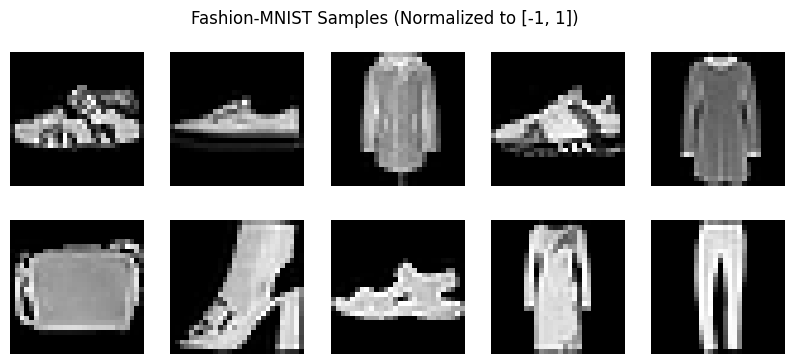

Dataset size: 60000
Image shape: torch.Size([1, 28, 28])


In [4]:
# Transform: [-1, 1] range for GANs
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # Maps [0,1] to [-1,1]
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Visualize sample
def show_sample_images():
    images, _ = next(iter(train_loader))
    fig, axes = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(axes.flat):
        img = images[i][0].cpu().numpy()
        ax.imshow(img, cmap='gray', vmin=-1, vmax=1)
        ax.axis('off')
    plt.suptitle('Fashion-MNIST Samples (Normalized to [-1, 1])')
    plt.show()

show_sample_images()
print(f"Dataset size: {len(train_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

In [5]:
class VanillaGenerator(nn.Module):
    """Fully connected generator"""
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28*28),
            nn.Tanh()  # Output range [-1, 1]
        )

    def forward(self, z):
        return self.model(z).view(-1, 1, 28, 28)

class VanillaDiscriminator(nn.Module):
    """Fully connected discriminator"""
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28*28, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.model(x)

In [ ]:
class DCGANGenerator(nn.Module):
    """Deep Convolutional GAN Generator"""
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            # Input: latent_dim x 1 x 1
            nn.ConvTranspose2d(latent_dim, 512, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            # 512 x 4 x 4
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            # 256 x 8 x 8
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # 128 x 14 x 14
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()
            # 1 x 28 x 28
        )

    def forward(self, z):
        z = z.view(z.size(0), z.size(1), 1, 1)
        return self.model(z)

class DCGANDiscriminator(nn.Module):
    """Deep Convolutional GAN Discriminator"""
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            # 128 x 14 x 14
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            # 256 x 7 x 7
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            # 512 x 3 x 3
            nn.Conv2d(512, 1, kernel_size=3, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)

In [14]:
def bce_loss(real_output, fake_output):
    """Binary Cross Entropy Loss"""
    criterion = nn.BCELoss()

    # Ensure both outputs are 1D or 2D with same shape
    real_output_reshaped = real_output.view(-1, 1)
    fake_output_reshaped = fake_output.view(-1, 1)

    # Discriminator loss
    real_labels_d = torch.ones_like(real_output_reshaped)
    fake_labels_d = torch.zeros_like(fake_output_reshaped)
    d_loss = criterion(real_output_reshaped, real_labels_d) + criterion(fake_output_reshaped, fake_labels_d)

    # Generator loss: wants fake images to be classified as real
    # The target labels for the generator's fake output must match its size
    generator_target_labels = torch.ones_like(fake_output_reshaped)
    g_loss = criterion(fake_output_reshaped, generator_target_labels)
    return d_loss, g_loss

def lsgan_loss(real_output, fake_output):
    """Least Squares GAN Loss"""
    real_output_reshaped = real_output.view(-1, 1)
    fake_output_reshaped = fake_output.view(-1, 1)

    # Discriminator loss
    real_labels_d = torch.ones_like(real_output_reshaped)
    fake_labels_d = torch.zeros_like(fake_output_reshaped)
    d_loss = 0.5 * torch.mean((real_output_reshaped - real_labels_d)**2) + 0.5 * torch.mean((fake_output_reshaped - fake_labels_d)**2)

    # Generator loss: wants fake images to be classified as real
    # The target labels for the generator's fake output must match its size
    generator_target_labels = torch.ones_like(fake_output_reshaped)
    g_loss = 0.5 * torch.mean((fake_output_reshaped - generator_target_labels)**2)
    return d_loss, g_loss

def wgan_loss(real_output, fake_output):
    """Wasserstein GAN Loss"""
    real_output = real_output.view(-1, 1)
    fake_output = fake_output.view(-1, 1)

    d_loss = torch.mean(fake_output) - torch.mean(real_output)
    g_loss = -torch.mean(fake_output)
    return d_loss, g_loss

In [12]:
def train_gan(generator, discriminator, train_loader, loss_type='bce',
              optimizer_type='adam', epochs=50, latent_dim=100):

    # Setup optimizers
    if optimizer_type == 'adam':
        g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
        d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
    elif optimizer_type == 'rmsprop':
        g_optimizer = optim.RMSprop(generator.parameters(), lr=0.00005)
        d_optimizer = optim.RMSprop(discriminator.parameters(), lr=0.00005)
    else:  # sgd
        g_optimizer = optim.SGD(generator.parameters(), lr=0.0001, momentum=0.9)
        d_optimizer = optim.SGD(discriminator.parameters(), lr=0.0001, momentum=0.9)

    history = {'g_loss': [], 'd_loss': []}
    fixed_noise = torch.randn(16, latent_dim, device=device)

    for epoch in range(epochs):
        g_losses = []
        d_losses = []

        for real_images, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            batch_size = real_images.size(0)
            real_images = real_images.to(device)

            # ========== TRAIN DISCRIMINATOR ==========
            d_optimizer.zero_grad()

            # Real images
            real_output = discriminator(real_images)

            # Fake images
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise)
            fake_output = discriminator(fake_images.detach())

            # Discriminator loss
            if loss_type == 'bce':
                d_loss, _ = bce_loss(real_output, fake_output)
            elif loss_type == 'lsgan':
                d_loss, _ = lsgan_loss(real_output, fake_output)
            else:  # wgan
                d_loss, _ = wgan_loss(real_output, fake_output)
                for p in discriminator.parameters():
                    p.data.clamp_(-0.01, 0.01)

            d_loss.backward()
            d_optimizer.step()

            # ========== TRAIN GENERATOR ==========
            g_optimizer.zero_grad()

            # Generate NEW fake images (don't reuse from discriminator step)
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise)
            fake_output = discriminator(fake_images)

            # Generator loss
            if loss_type == 'bce':
                _, g_loss = bce_loss(real_output, fake_output)
            elif loss_type == 'lsgan':
                _, g_loss = lsgan_loss(real_output, fake_output)
            else:  # wgan
                _, g_loss = wgan_loss(real_output, fake_output)

            g_loss.backward()
            g_optimizer.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        history['g_loss'].append(np.mean(g_losses))
        history['d_loss'].append(np.mean(d_losses))

        # Print progress
        print(f"Epoch {epoch+1}/{epochs} - G Loss: {history['g_loss'][-1]:.4f}, D Loss: {history['d_loss'][-1]:.4f}")

        # Generate and save images
        if (epoch + 1) % 10 == 0:
            generator.eval()
            with torch.no_grad():
                fake = generator(fixed_noise).cpu()

            fig, axes = plt.subplots(4, 4, figsize=(8, 8))
            for i, ax in enumerate(axes.flat):
                ax.imshow(fake[i][0], cmap='gray', vmin=-1, vmax=1)
                ax.axis('off')
            plt.suptitle(f'{loss_type.upper()}-{optimizer_type} - Epoch {epoch+1}')
            plt.savefig(f'{exp_path}/results/{loss_type}_{optimizer_type}_epoch{epoch+1}.png')
            plt.close()
            generator.train()

    return generator, discriminator, history


Training Vanilla GAN with BCE loss


Epoch 50/50: 100%|██████████| 469/469 [00:16<00:00, 28.50it/s]


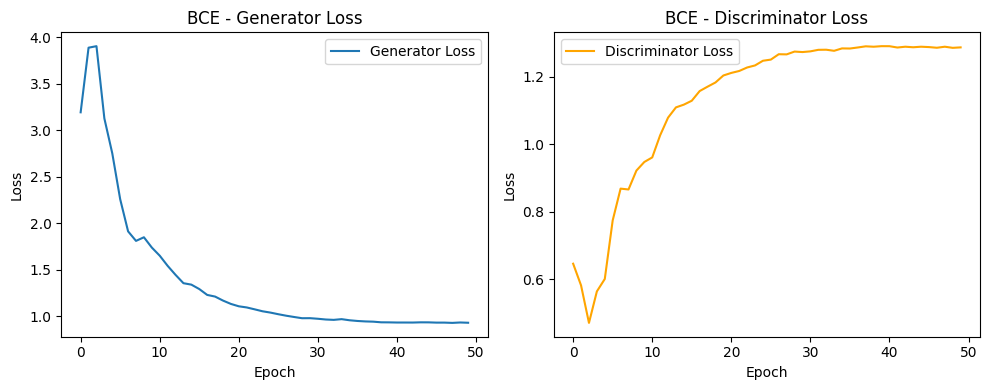


Training Vanilla GAN with LSGAN loss


Epoch 50/50: 100%|██████████| 469/469 [00:15<00:00, 31.03it/s]


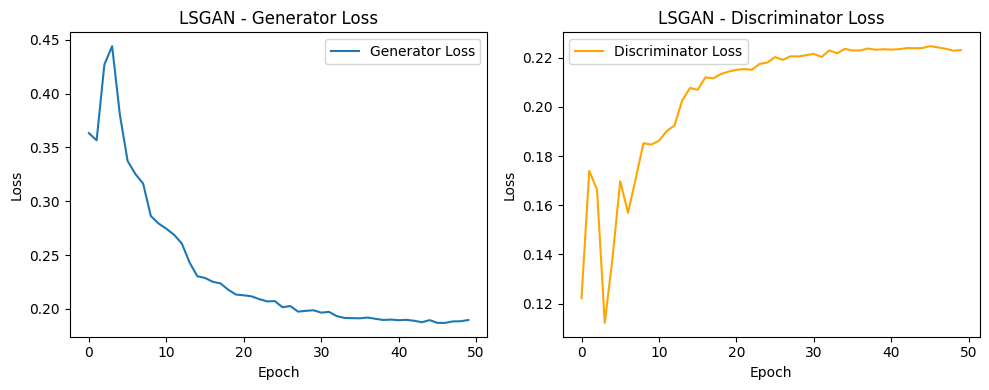


Training Vanilla GAN with WGAN loss


Epoch 50/50: 100%|██████████| 469/469 [00:15<00:00, 30.32it/s]


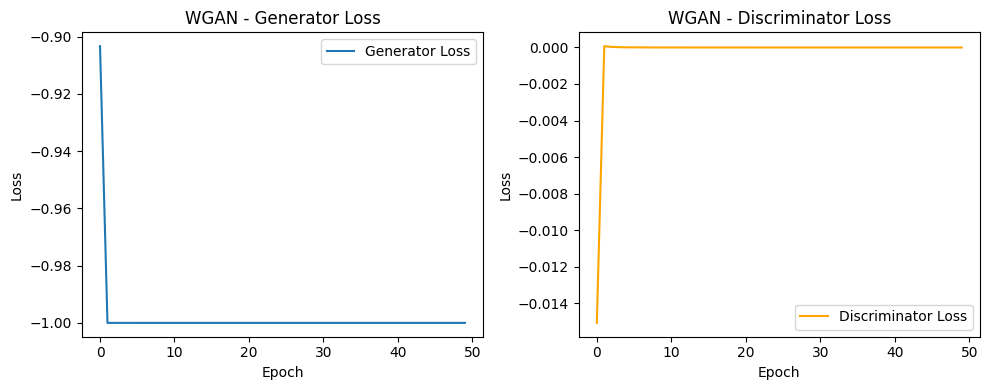

In [9]:
latent_dim = 100
epochs = 50

loss_functions = ['bce', 'lsgan', 'wgan']
results = {}

for loss in loss_functions:
    print(f"\n{'='*50}")
    print(f"Training Vanilla GAN with {loss.upper()} loss")
    print(f"{'='*50}")

    generator = VanillaGenerator(latent_dim).to(device)
    discriminator = VanillaDiscriminator().to(device)

    gen, disc, history = train_gan(generator, discriminator, train_loader,
                                    loss_type=loss, optimizer_type='adam',
                                    epochs=epochs, latent_dim=latent_dim)

    results[loss] = {'generator': gen, 'history': history}

    # Save model
    torch.save(gen.state_dict(), f'{exp_path}/models/vanilla_gan_{loss}.pt')

    # Plot loss curves
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['g_loss'], label='Generator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{loss.upper()} - Generator Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['d_loss'], label='Discriminator Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{loss.upper()} - Discriminator Loss')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{exp_path}/results/vanilla_{loss}_losses.png')
    plt.show()


Training DCGAN with ADAM optimizer


Epoch 1/20: 100%|██████████| 469/469 [01:01<00:00,  7.66it/s]


Epoch 1/20 - G Loss: 7.1093, D Loss: 0.0126


Epoch 2/20: 100%|██████████| 469/469 [01:00<00:00,  7.81it/s]


Epoch 2/20 - G Loss: 8.8770, D Loss: 0.0003


...

Epoch 18/20 - G Loss: 16.1225, D Loss: 0.0000


Epoch 19/20: 100%|██████████| 469/469 [00:59<00:00,  7.92it/s]


Epoch 19/20 - G Loss: 17.0478, D Loss: 0.0000


Epoch 20/20: 100%|██████████| 469/469 [00:59<00:00,  7.89it/s]


Epoch 20/20 - G Loss: 17.0017, D Loss: 0.0000


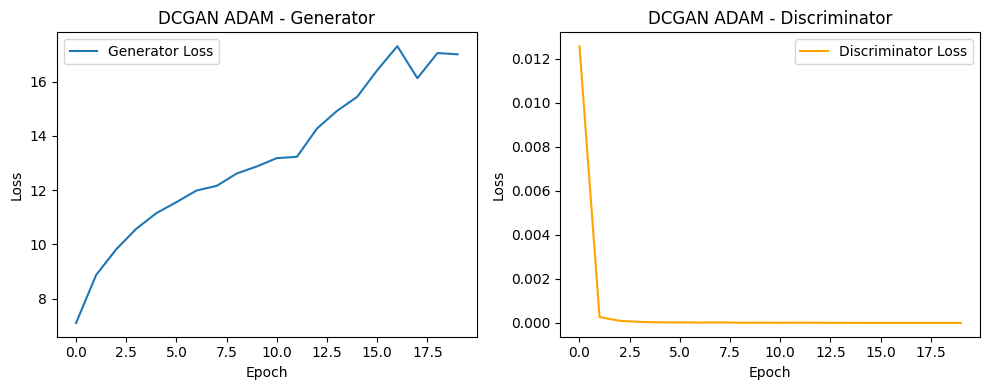


Training DCGAN with RMSPROP optimizer


Epoch 1/20: 100%|██████████| 469/469 [00:59<00:00,  7.86it/s]


Epoch 1/20 - G Loss: 6.6209, D Loss: 0.0185


Epoch 2/20: 100%|██████████| 469/469 [00:59<00:00,  7.87it/s]


Epoch 2/20 - G Loss: 9.1440, D Loss: 0.0002


...

Epoch 18/20 - G Loss: 25.0030, D Loss: 0.0000


Epoch 19/20: 100%|██████████| 469/469 [00:58<00:00,  7.99it/s]


Epoch 19/20 - G Loss: 25.8922, D Loss: 0.0000


Epoch 20/20: 100%|██████████| 469/469 [00:58<00:00,  7.95it/s]


Epoch 20/20 - G Loss: 25.6424, D Loss: 0.0000


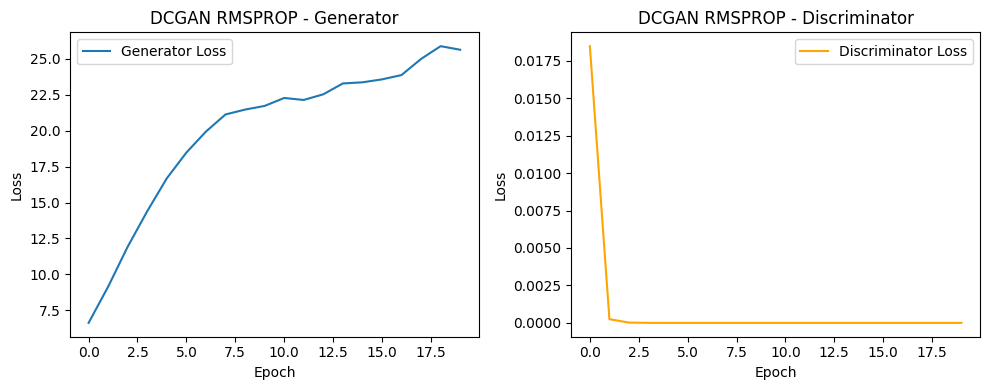


Training DCGAN with SGD optimizer


Epoch 1/20: 100%|██████████| 469/469 [01:00<00:00,  7.79it/s]


Epoch 1/20 - G Loss: 3.6881, D Loss: 0.1153


Epoch 2/20: 100%|██████████| 469/469 [01:00<00:00,  7.80it/s]


Epoch 2/20 - G Loss: 5.2689, D Loss: 0.0112


...

Epoch 18/20 - G Loss: 7.3478, D Loss: 0.0011


Epoch 19/20: 100%|██████████| 469/469 [00:59<00:00,  7.83it/s]


Epoch 19/20 - G Loss: 7.3308, D Loss: 0.0011


Epoch 20/20: 100%|██████████| 469/469 [00:59<00:00,  7.89it/s]


Epoch 20/20 - G Loss: 7.7243, D Loss: 0.0008


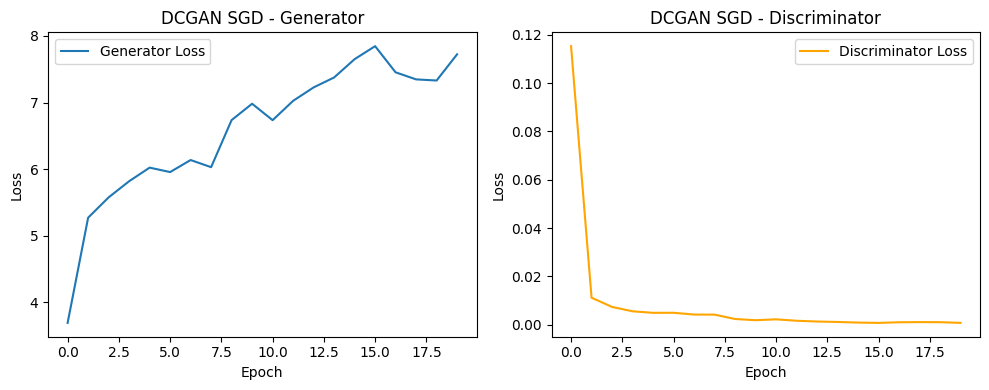

In [17]:
latent_dim = 100
epochs = 20

optimizers = ['adam', 'rmsprop', 'sgd']
dcgan_results = {}

for opt in optimizers:
    print(f"\n{'='*50}")
    print(f"Training DCGAN with {opt.upper()} optimizer")
    print(f"{'='*50}")

    generator = DCGANGenerator(latent_dim).to(device)
    discriminator = DCGANDiscriminator().to(device)

    gen, disc, history = train_gan(generator, discriminator, train_loader,
                                    loss_type='bce', optimizer_type=opt,
                                    epochs=epochs, latent_dim=latent_dim)

    dcgan_results[opt] = {'generator': gen, 'history': history}

    torch.save(gen.state_dict(), f'{exp_path}/models/dcgan_{opt}.pt')

    # Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['g_loss'], label='Generator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'DCGAN {opt.upper()} - Generator')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history['d_loss'], label='Discriminator Loss', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'DCGAN {opt.upper()} - Discriminator')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{exp_path}/results/dcgan_{opt}_losses.png')
    plt.show()


COMPARISON: Vanilla GAN vs DCGAN


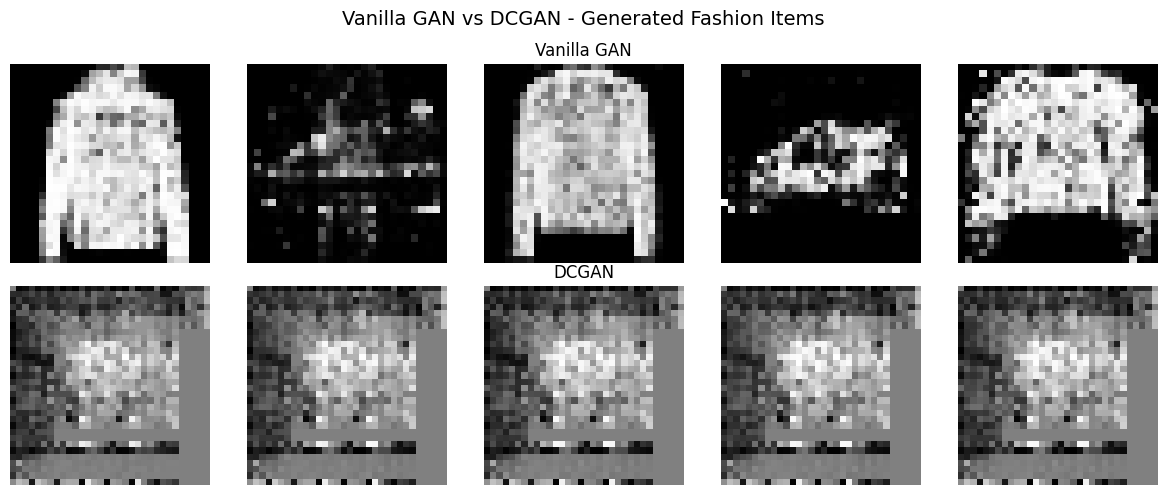

In [18]:
print("\n" + "="*60)
print("COMPARISON: Vanilla GAN vs DCGAN")
print("="*60)

# Generate images from best models
latent_dim = 100
fixed_noise = torch.randn(64, latent_dim, device=device)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Vanilla GAN (BCE)
vanilla_gen = VanillaGenerator(latent_dim).to(device)
vanilla_gen.load_state_dict(torch.load(f'{exp_path}/models/vanilla_gan_bce.pt'))
vanilla_gen.eval()

with torch.no_grad():
    vanilla_images = vanilla_gen(fixed_noise[:5]).cpu()

for i in range(5):
    axes[0, i].imshow(vanilla_images[i][0], cmap='gray', vmin=-1, vmax=1)
    axes[0, i].axis('off')
    if i == 2:
        axes[0, i].set_title('Vanilla GAN', fontsize=12)

# DCGAN (Adam)
dcgan_gen = DCGANGenerator(latent_dim).to(device)
dcgan_gen.load_state_dict(torch.load(f'{exp_path}/models/dcgan_adam.pt'))
dcgan_gen.eval()

with torch.no_grad():
    dcgan_images = dcgan_gen(fixed_noise[:5]).cpu()

for i in range(5):
    axes[1, i].imshow(dcgan_images[i][0], cmap='gray', vmin=-1, vmax=1)
    axes[1, i].axis('off')
    if i == 2:
        axes[1, i].set_title('DCGAN', fontsize=12)

plt.suptitle('Vanilla GAN vs DCGAN - Generated Fashion Items', fontsize=14)
plt.tight_layout()
plt.savefig(f'{exp_path}/results/vanilla_vs_dcgan.png')
plt.show()

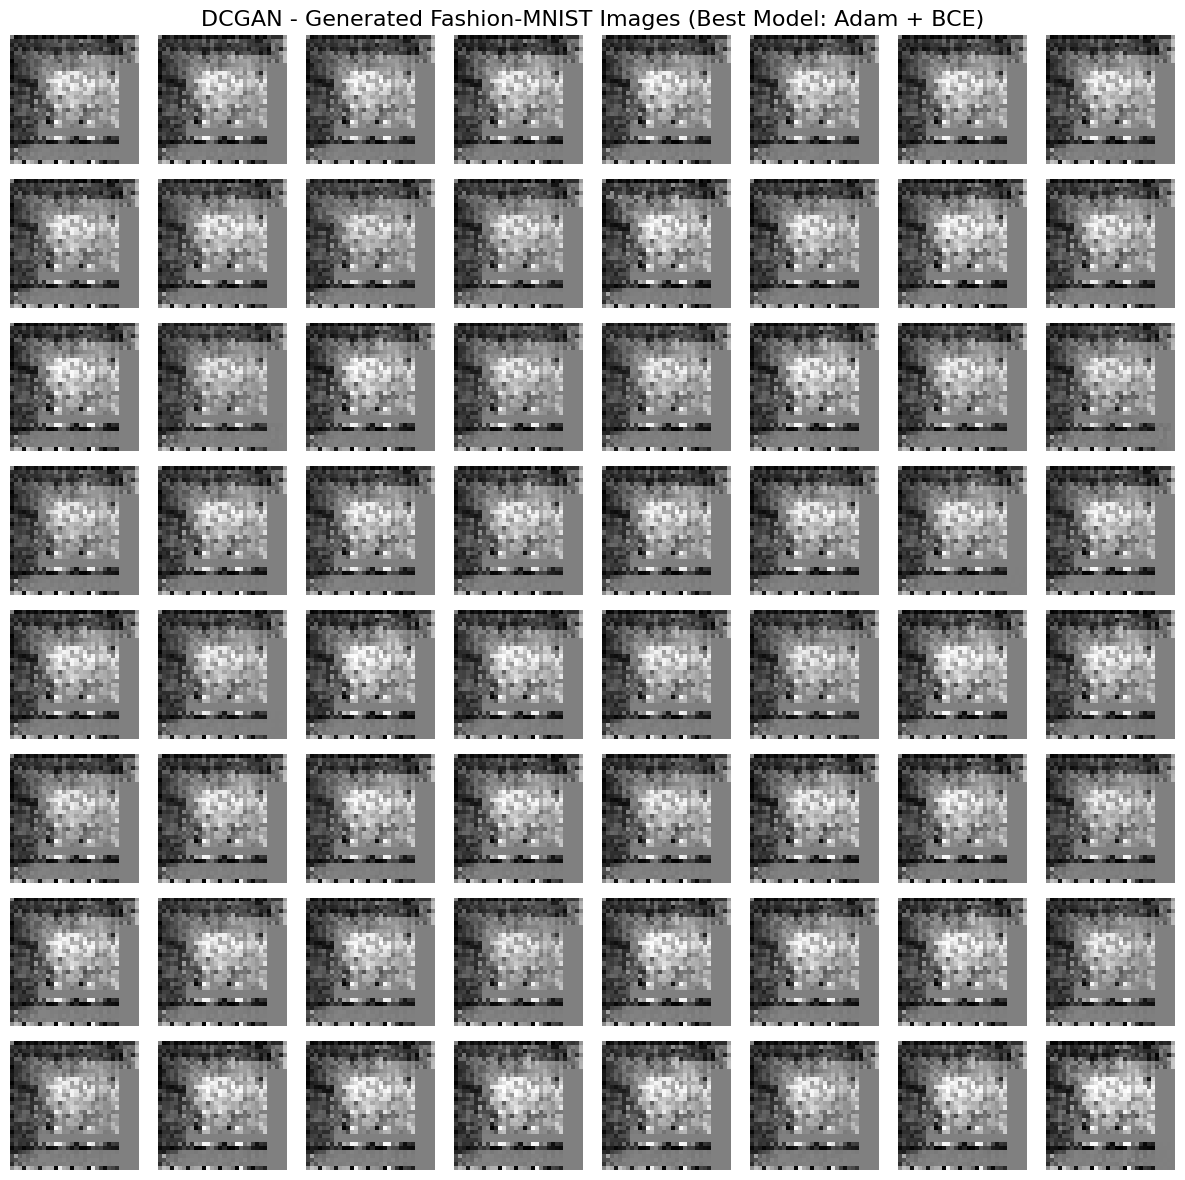


EXPERIMENT 9 COMPLETED

📁 Results saved to: /content/drive/MyDrive/DEEP LEARNING LAB/Experiment 9
   - models/ - Trained model weights
   - results/ - Generated images and loss plots

📊 BEST CONFIGURATION:
   - Architecture: DCGAN
   - Loss: BCE
   - Optimizer: Adam
   - Learning Rate: 0.0002
   - Latent Dim: 100


In [19]:
# Generate a grid of final images from best DCGAN
best_gen = DCGANGenerator(latent_dim).to(device)
best_gen.load_state_dict(torch.load(f'{exp_path}/models/dcgan_adam.pt'))
best_gen.eval()

num_samples = 64
noise = torch.randn(num_samples, latent_dim, device=device)

with torch.no_grad():
    generated = best_gen(noise).cpu()

# Create 8x8 grid
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i][0], cmap='gray', vmin=-1, vmax=1)
    ax.axis('off')

plt.suptitle('DCGAN - Generated Fashion-MNIST Images (Best Model: Adam + BCE)', fontsize=16)
plt.tight_layout()
plt.savefig(f'{exp_path}/results/final_generated_grid.png', dpi=150)
plt.show()

print("\n" + "="*60)
print("EXPERIMENT 9 COMPLETED")
print("="*60)
print(f"\n📁 Results saved to: {exp_path}")
print("   - models/ - Trained model weights")
print("   - results/ - Generated images and loss plots")
print("\n📊 BEST CONFIGURATION:")
print("   - Architecture: DCGAN")
print("   - Loss: BCE")
print("   - Optimizer: Adam")
print("   - Learning Rate: 0.0002")
print("   - Latent Dim: 100")